In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Exploratory Data Analysis: YouTube Video Viewership
This notebook performs exploratory data analysis and visualization of YouTube video viewership data.
It covers viewership growth curves, distributions, engagement analysis, publishing patterns, early signals, and channel-level overviews.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Set consistent styling
sns.set_style("darkgrid")
sns.set_palette("muted")

# Load datasets
channel_stats = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/channel_stats_updated.csv')
videos_rows = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/videos_rows_updated.csv')
view_timeseries = pd.read_csv('/content/drive/Othercomputers/My Laptop/models/view_timeseries.csv')

# 1. Convert view_count, like_count, comment_count to numeric, drop nulls
numeric_cols = ['view_count', 'like_count', 'comment_count']
for col in numeric_cols:
    view_timeseries[col] = pd.to_numeric(view_timeseries[col], errors='coerce')
view_timeseries.dropna(subset=numeric_cols, inplace=True)

# 2. Convert all datetime columns
datetime_cols_channel = ['processed_at', 'created_at']
for col in datetime_cols_channel:
    channel_stats[col] = pd.to_datetime(channel_stats[col], errors='coerce')

datetime_cols_videos = ['published_at', 'last_polled_at', 'next_poll_at', 'created_at']
for col in datetime_cols_videos:
    videos_rows[col] = pd.to_datetime(videos_rows[col], errors='coerce')

datetime_cols_ts = ['scraped_at']
for col in datetime_cols_ts:
    view_timeseries[col] = pd.to_datetime(view_timeseries[col], errors='coerce')

# 3. Compute hours_since_publish by merging view_timeseries with videos_rows
vt_merged = view_timeseries.merge(videos_rows[['video_id', 'channel_id', 'published_at']], on='video_id', how='left')
vt_merged['hours_since_publish'] = (vt_merged['scraped_at'] - vt_merged['published_at']).dt.total_seconds() / 3600.0

# 4. Drop rows where hours_since_publish < 0
vt_merged = vt_merged[vt_merged['hours_since_publish'] >= 0]

# 5. Merge channel_title into the timeseries data via channel_id
vt_merged = vt_merged.merge(channel_stats[['channel_id', 'channel_title']], on='channel_id', how='left')

# Prepare latest and earliest snapshots for later sections
vt_sorted = vt_merged.sort_values(['video_id', 'hours_since_publish'])
latest_snapshot = vt_sorted.groupby('video_id').last().reset_index()
early_snapshot = vt_sorted.groupby('video_id').first().reset_index()


## 1. Viewership Growth Curves
This section visualizes how video viewership grows over time.
- The first plot shows a random sample of 12 videos to understand general growth trajectories on a logarithmic scale.
- The subplots show detailed metrics (views, likes, comments) for 4 high-performing videos.
- The interactive section allows you to manually input specific video IDs to compare their growth side-by-side.


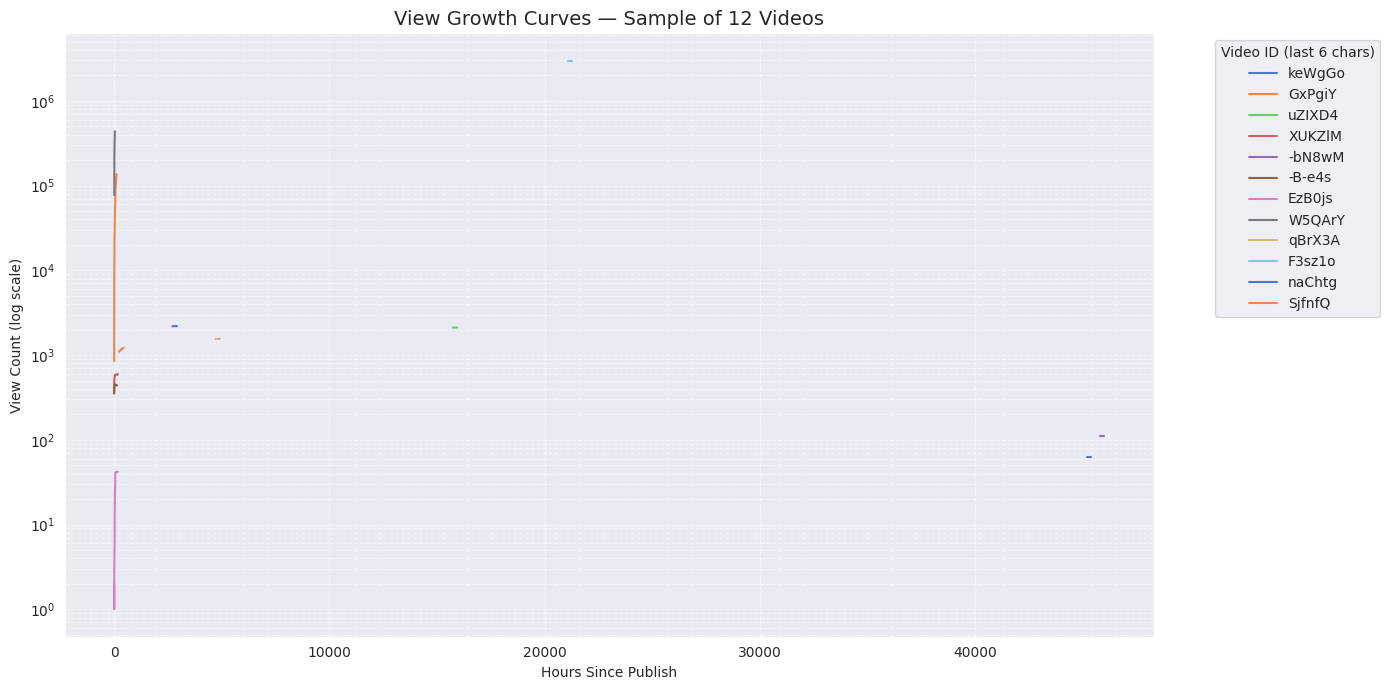

In [3]:
# View Growth Curves — Sample of 12 Videos
sample_videos = np.random.choice(vt_merged['video_id'].unique(), size=12, replace=False)
sample_data = vt_merged[vt_merged['video_id'].isin(sample_videos)]

plt.figure(figsize=(14, 7))
for vid in sample_videos:
    vid_data = sample_data[sample_data['video_id'] == vid]
    plt.plot(vid_data['hours_since_publish'], vid_data['view_count'], label=vid[-6:])

plt.yscale('log')
plt.title('View Growth Curves — Sample of 12 Videos', fontsize=14)
plt.xlabel('Hours Since Publish')
plt.ylabel('View Count (log scale)')
plt.legend(title='Video ID (last 6 chars)', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


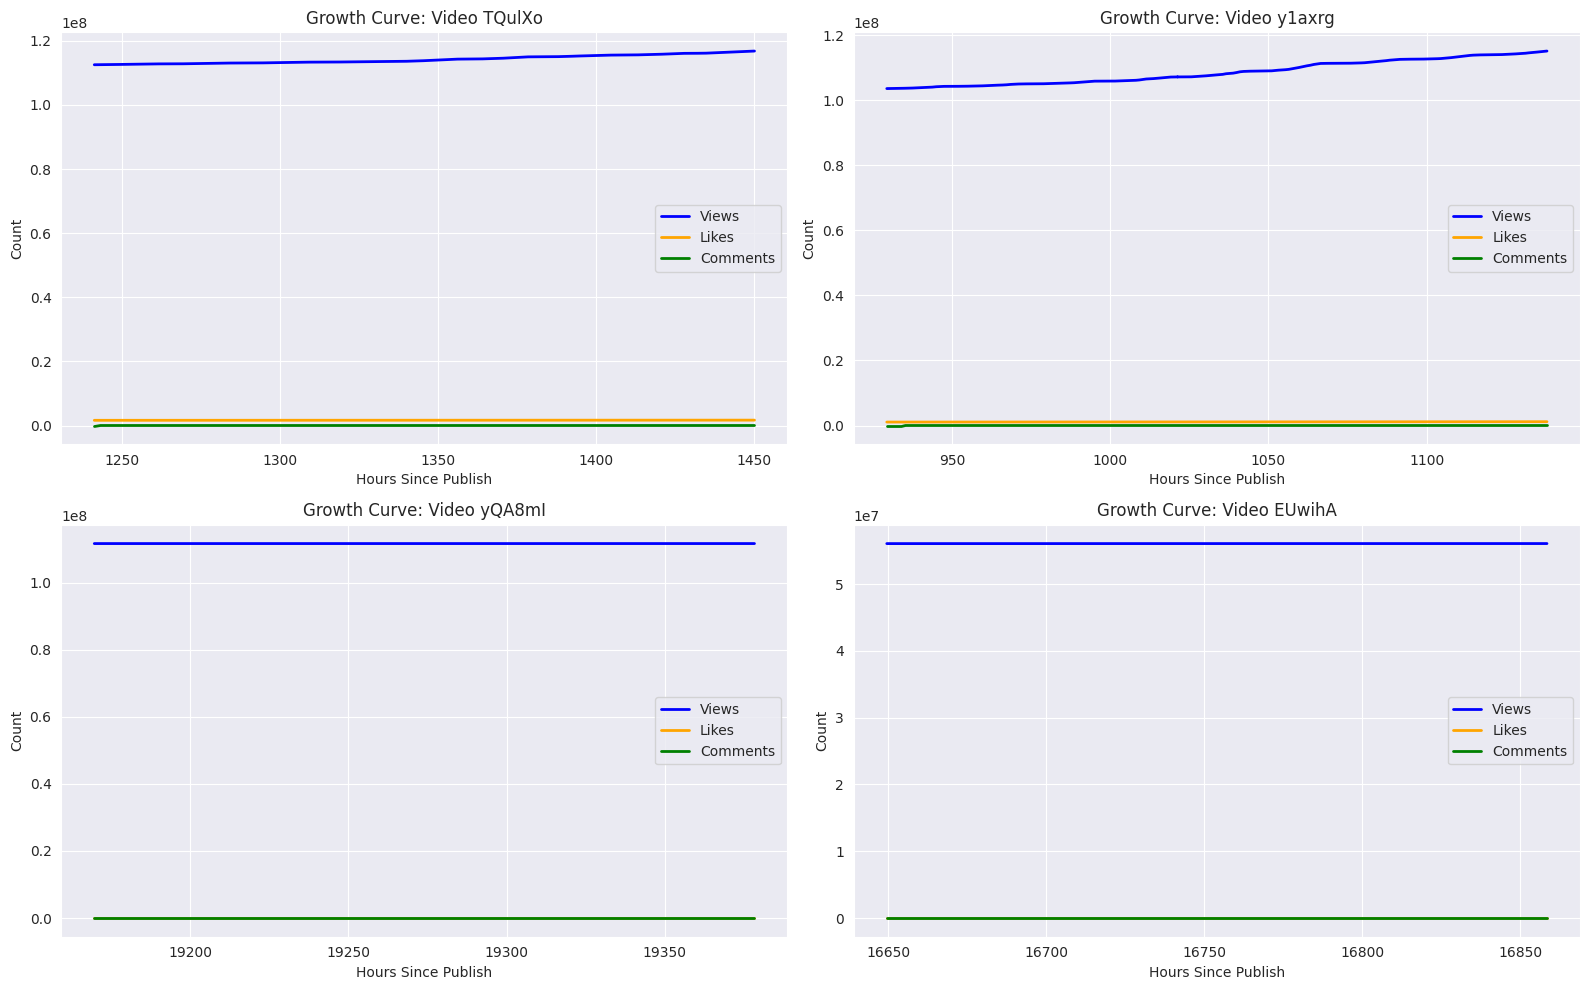

In [4]:
# 4 separate subplots for 4 interesting videos
# Find videos with at least 20 scrape points
scrape_counts = vt_merged['video_id'].value_counts()
videos_with_20_plus = scrape_counts[scrape_counts >= 20].index

# Among these, get the 4 with the highest final view count
top_4_videos = latest_snapshot[latest_snapshot['video_id'].isin(videos_with_20_plus)].sort_values('view_count', ascending=False).head(4)['video_id'].values

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, vid in enumerate(top_4_videos):
    vid_data = vt_merged[vt_merged['video_id'] == vid]

    axes[i].plot(vid_data['hours_since_publish'], vid_data['view_count'], label='Views', color='blue', linewidth=2)
    axes[i].plot(vid_data['hours_since_publish'], vid_data['like_count'], label='Likes', color='orange', linewidth=2)
    axes[i].plot(vid_data['hours_since_publish'], vid_data['comment_count'], label='Comments', color='green', linewidth=2)

    axes[i].set_title(f'Growth Curve: Video {vid[-6:]}')
    axes[i].set_xlabel('Hours Since Publish')
    axes[i].set_ylabel('Count')
    axes[i].legend()
    axes[i].grid(True)

plt.tight_layout()
plt.show()


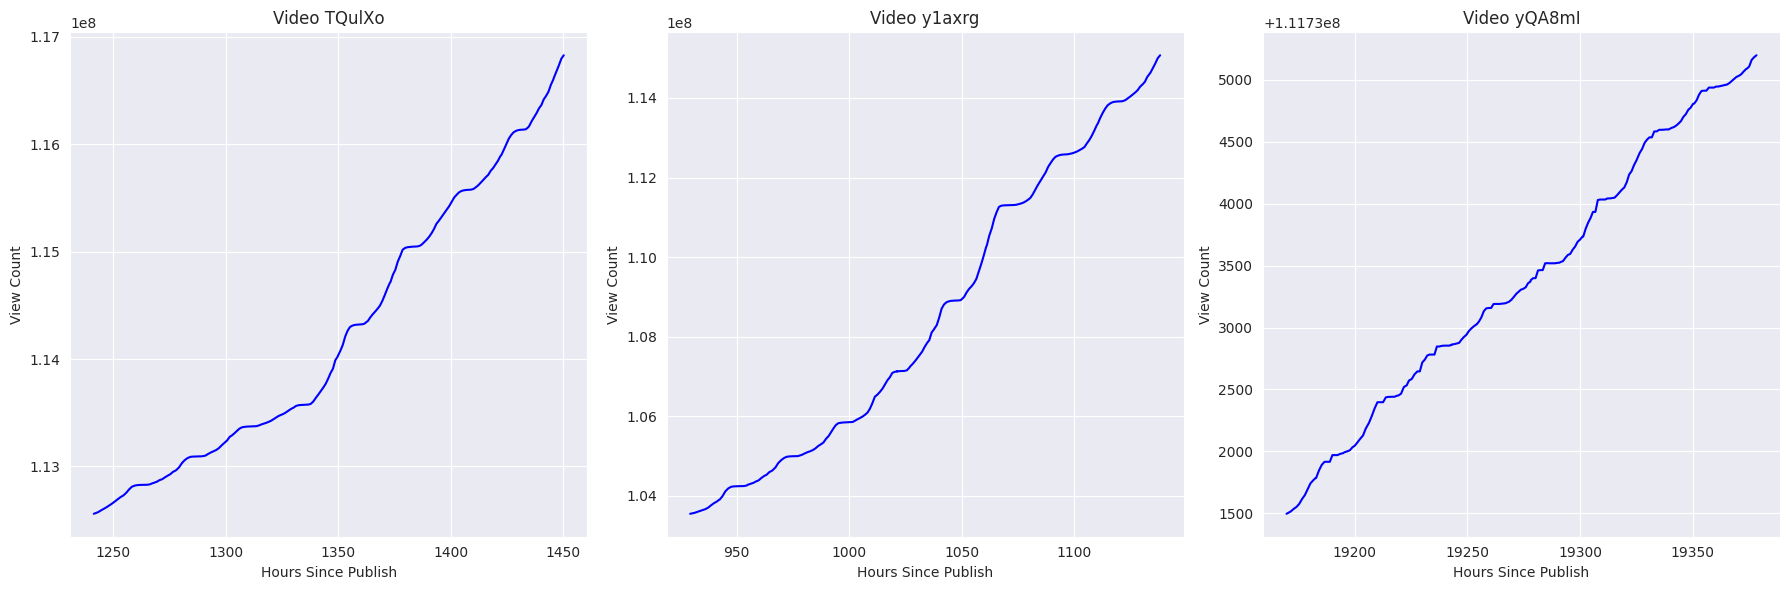

In [5]:
# Manual input for video IDs comparison
# Replace the list below with your own video_ids of interest
manual_video_ids = list(top_4_videos[:3])  # Using top 3 as a default placeholder

if len(manual_video_ids) > 0:
    fig, axes = plt.subplots(1, len(manual_video_ids), figsize=(6 * len(manual_video_ids), 6))
    if len(manual_video_ids) == 1:
        axes = [axes]

    for i, vid in enumerate(manual_video_ids):
        vid_data = vt_merged[vt_merged['video_id'] == vid]
        if vid_data.empty:
            axes[i].text(0.5, 0.5, f'No data for {vid[-6:]}', ha='center', va='center')
            continue

        axes[i].plot(vid_data['hours_since_publish'], vid_data['view_count'], label='Views', color='blue')
        axes[i].set_title(f'Video {vid[-6:]}')
        axes[i].set_xlabel('Hours Since Publish')
        axes[i].set_ylabel('View Count')
        axes[i].grid(True)

    plt.tight_layout()
    plt.show()


## 2. View Count Distribution
This section analyzes the distribution of the final (latest) view counts across all videos.
- A histogram shows the overall spread of final view counts on a logarithmic scale, highlighting the mean and median.
- A box plot breaks down the view count distributions for the top 15 channels (by number of tracked videos) to show variance between channels.


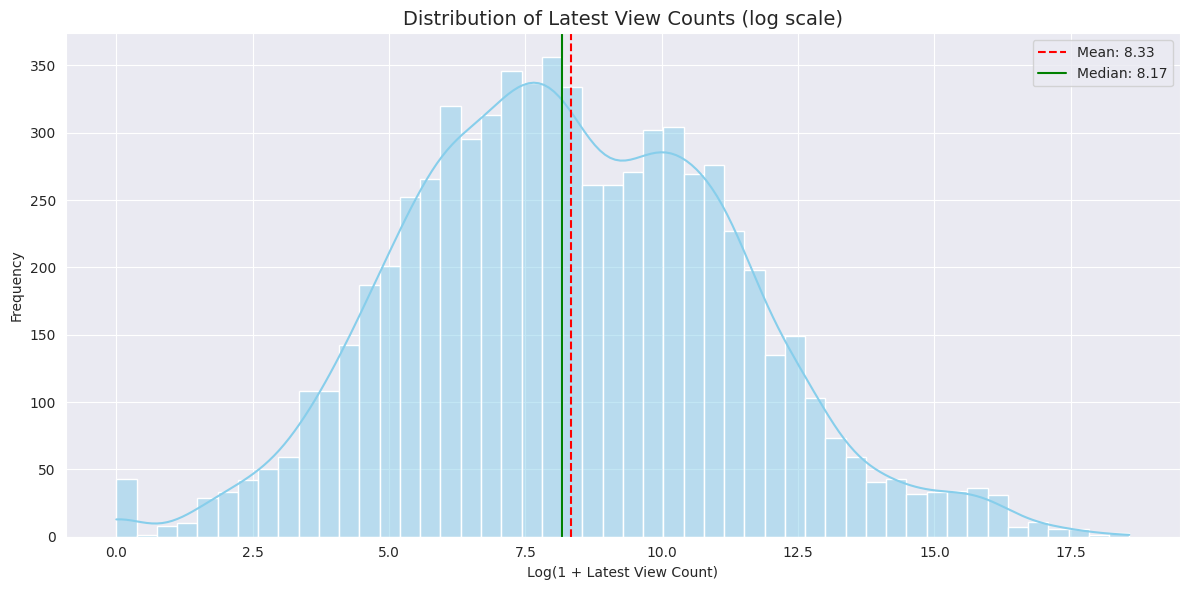

/tmp/ipykernel_2263/3762403472.py:32: UserWarning: Glyph 3520 (\N{SINHALA LETTER VAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/3762403472.py:32: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipykernel_2263/3762403472.py:32: UserWarning: Glyph 3538 (\N{SINHALA VOWEL SIGN KETTI IS-PILLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/3762403472.py:32: UserWarning: Glyph 3521 (\N{SINHALA LETTER TAALUJA SAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/3762403472.py:32: UserWarning: Glyph 3530 (\N{SINHALA SIGN AL-LAKUNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/3762403472.py:32: UserWarning: Glyph 3482 (\N{SINHALA LETTER ALPAPRAANA KAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/3762403472.py:32: UserWarning: Glyph 3515 (\N{SINHALA LETTER RAYANNA}) missing from font(s) 

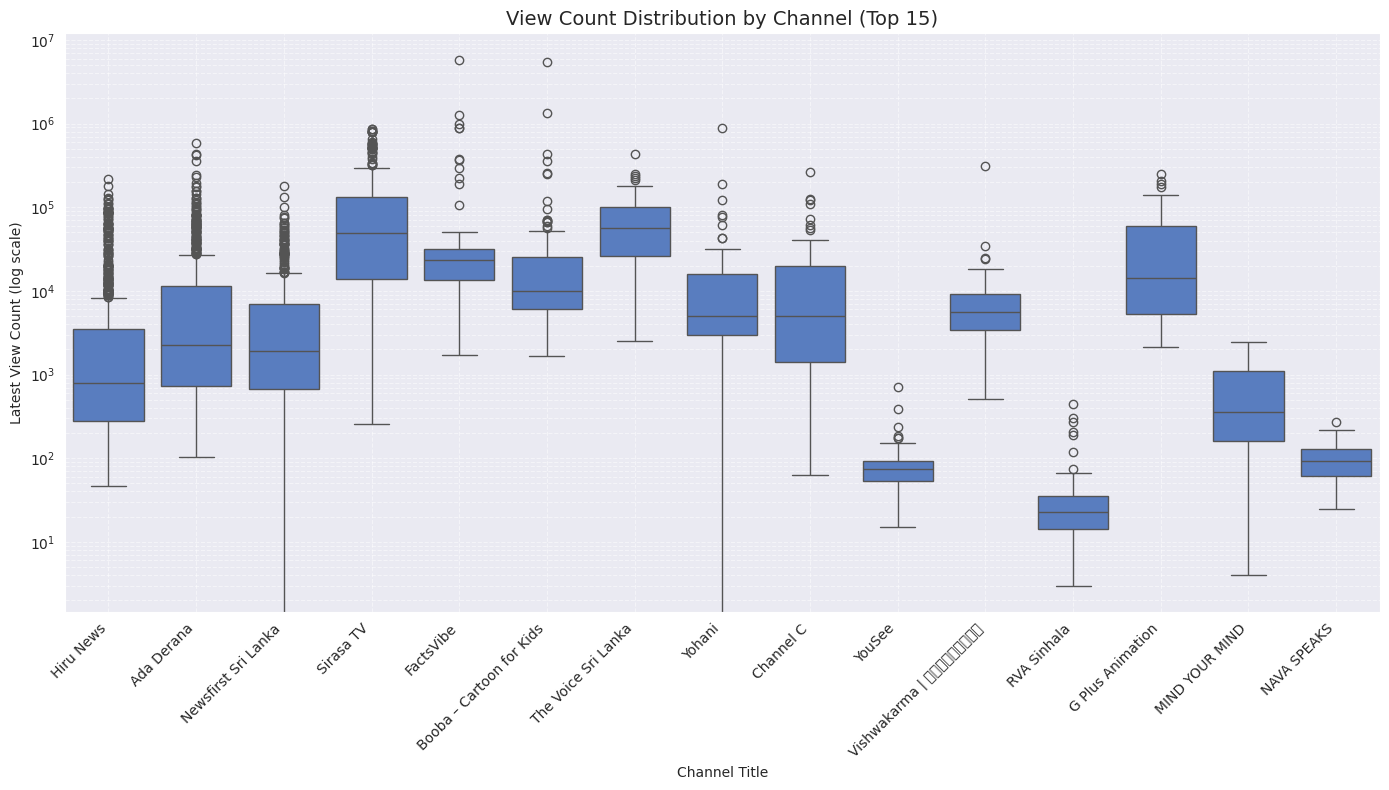

In [6]:
# Histogram of the latest view_count per video (log scale)
plt.figure(figsize=(12, 6))
log_views = np.log1p(latest_snapshot['view_count'])
sns.histplot(log_views, bins=50, kde=True, color='skyblue')

mean_val = log_views.mean()
median_val = log_views.median()

plt.axvline(mean_val, color='red', linestyle='--', label=f'Mean: {mean_val:.2f}')
plt.axvline(median_val, color='green', linestyle='-', label=f'Median: {median_val:.2f}')

plt.title('Distribution of Latest View Counts (log scale)', fontsize=14)
plt.xlabel('Log(1 + Latest View Count)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# Box plot of latest view_count by channel_title (Top 15 channels)
top_15_channels = latest_snapshot['channel_title'].value_counts().nlargest(15).index
top_15_data = latest_snapshot[latest_snapshot['channel_title'].isin(top_15_channels)]

plt.figure(figsize=(14, 8))
sns.boxplot(x='channel_title', y='view_count', data=top_15_data, order=top_15_channels)
plt.yscale('log')
plt.xticks(rotation=45, ha='right')
plt.title('View Count Distribution by Channel (Top 15)', fontsize=14)
plt.xlabel('Channel Title')
plt.ylabel('Latest View Count (log scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


## 3. Engagement Analysis
This section explores the relationship between views and engagement metrics (likes and comments).
- Scatter plots illustrate how likes and comments correlate with views. A trendline is plotted on the log-transformed data.
- A bar chart compares the average like engagement rate (likes per view) across the top 15 channels.


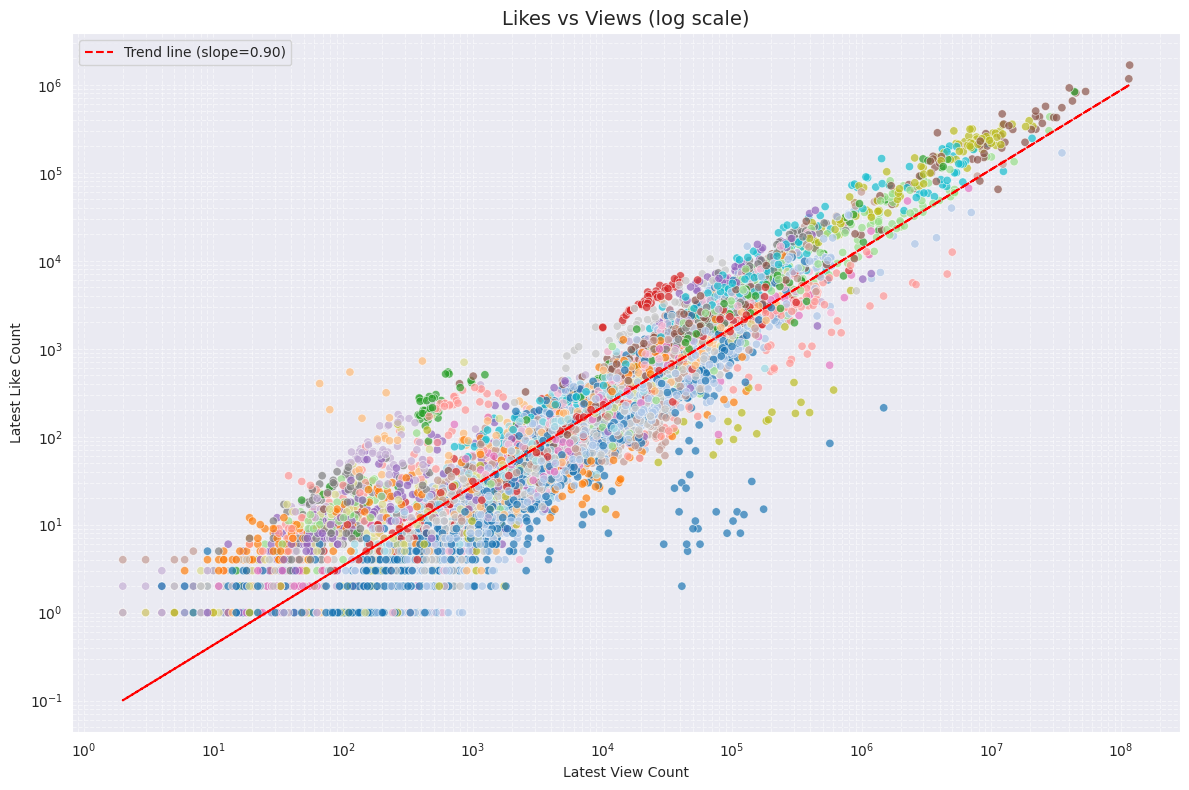

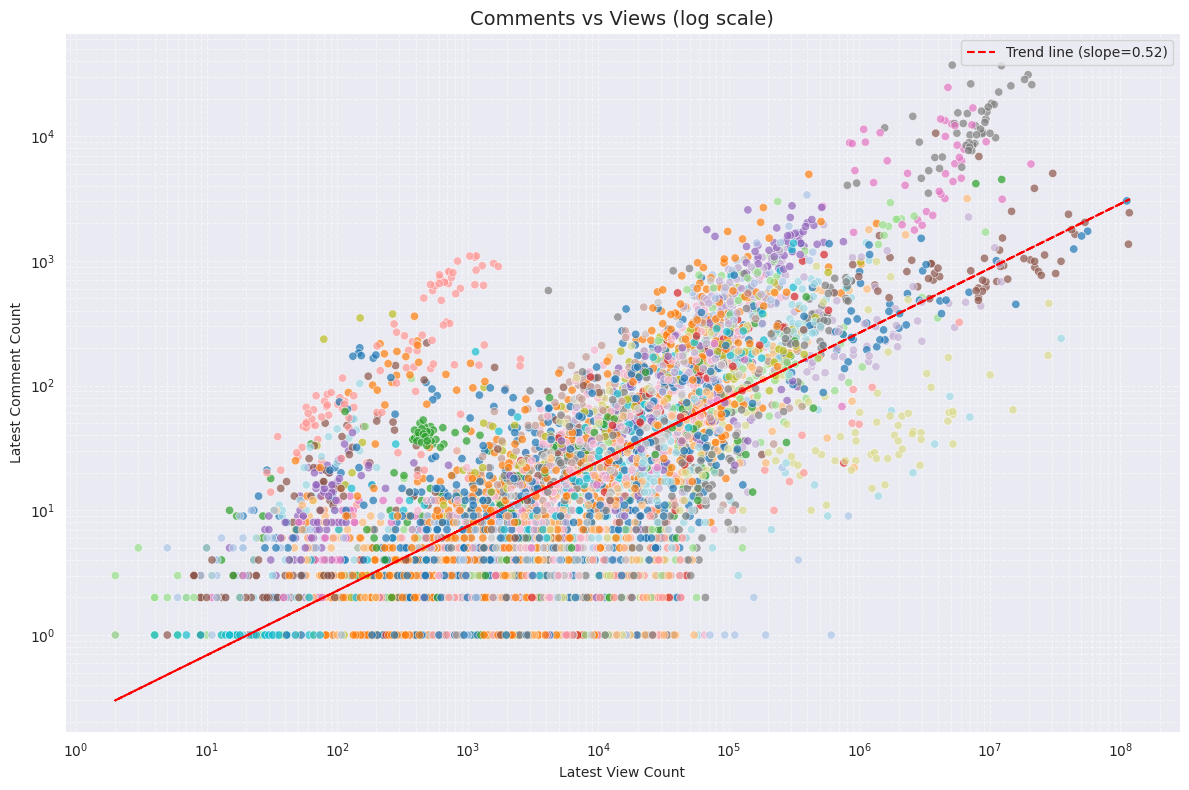

/tmp/ipykernel_2263/1512384391.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=engagement_by_channel.index, y=engagement_by_channel.values, palette='viridis')
/tmp/ipykernel_2263/1512384391.py:64: UserWarning: Glyph 3520 (\N{SINHALA LETTER VAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1512384391.py:64: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipykernel_2263/1512384391.py:64: UserWarning: Glyph 3538 (\N{SINHALA VOWEL SIGN KETTI IS-PILLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1512384391.py:64: UserWarning: Glyph 3521 (\N{SINHALA LETTER TAALUJA SAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1512384391.py:64: UserWarning: Glyph 3530 (\N{SINHALA SIGN AL-LAKUNA}) missing

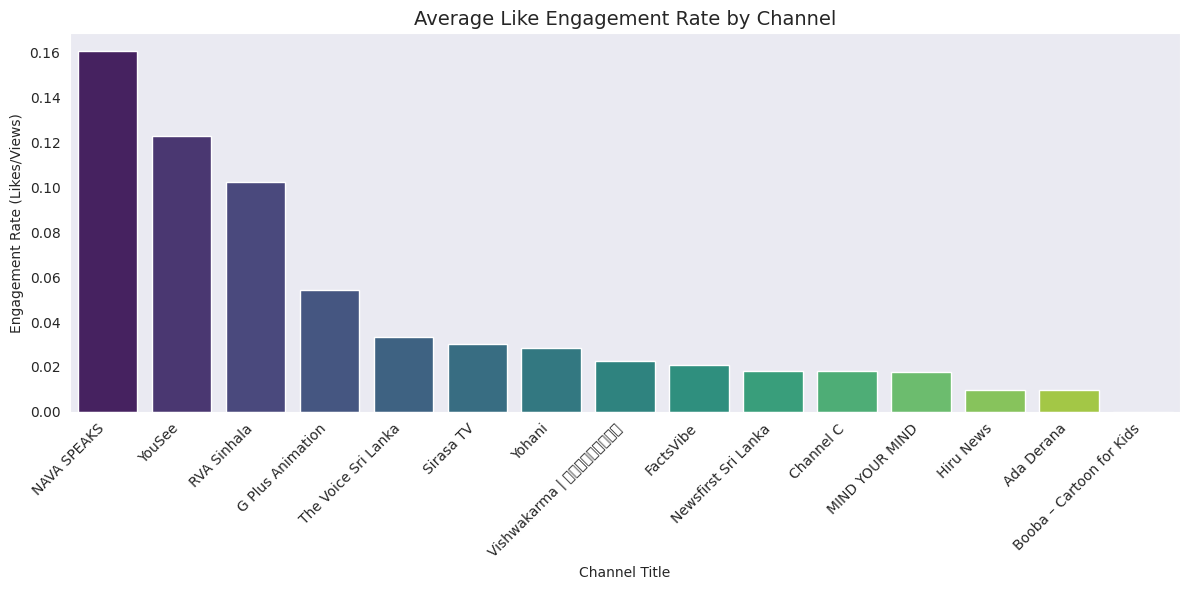

In [7]:
# Scatter plot: latest like_count vs latest view_count
# Filter out zeros for log transformation
valid_likes = latest_snapshot[(latest_snapshot['view_count'] > 0) & (latest_snapshot['like_count'] > 0)]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='view_count', y='like_count', hue='channel_title',
                data=valid_likes, alpha=0.7, legend=False, palette='tab20')

# Trend line on log values
log_x = np.log10(valid_likes['view_count'])
log_y = np.log10(valid_likes['like_count'])
z = np.polyfit(log_x, log_y, 1)
p = np.poly1d(z)
plt.plot(valid_likes['view_count'], 10**(p(log_x)), color='red', linestyle='--', label=f'Trend line (slope={z[0]:.2f})')

plt.xscale('log')
plt.yscale('log')
plt.title('Likes vs Views (log scale)', fontsize=14)
plt.xlabel('Latest View Count')
plt.ylabel('Latest Like Count')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Scatter plot: latest comment_count vs latest view_count
valid_comments = latest_snapshot[(latest_snapshot['view_count'] > 0) & (latest_snapshot['comment_count'] > 0)]

plt.figure(figsize=(12, 8))
sns.scatterplot(x='view_count', y='comment_count', hue='channel_title',
                data=valid_comments, alpha=0.7, legend=False, palette='tab20')

# Trend line on log values
log_x_c = np.log10(valid_comments['view_count'])
log_y_c = np.log10(valid_comments['comment_count'])
z_c = np.polyfit(log_x_c, log_y_c, 1)
p_c = np.poly1d(z_c)
plt.plot(valid_comments['view_count'], 10**(p_c(log_x_c)), color='red', linestyle='--', label=f'Trend line (slope={z_c[0]:.2f})')

plt.xscale('log')
plt.yscale('log')
plt.title('Comments vs Views (log scale)', fontsize=14)
plt.xlabel('Latest View Count')
plt.ylabel('Latest Comment Count')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Average engagement rate (likes / views) per channel for top 15 channels
latest_snapshot['engagement_rate'] = (latest_snapshot['like_count'] / latest_snapshot['view_count']).fillna(0)
latest_snapshot['engagement_rate'] = latest_snapshot['engagement_rate'].clip(upper=1.0) # Clip outliers

top_15_channels = latest_snapshot['channel_title'].value_counts().nlargest(15).index
engagement_by_channel = latest_snapshot[latest_snapshot['channel_title'].isin(top_15_channels)]    .groupby('channel_title')['engagement_rate'].mean().sort_values(ascending=False)

plt.figure(figsize=(12, 6))
sns.barplot(x=engagement_by_channel.index, y=engagement_by_channel.values, palette='viridis')
plt.title('Average Like Engagement Rate by Channel', fontsize=14)
plt.xlabel('Channel Title')
plt.ylabel('Engagement Rate (Likes/Views)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y')
plt.tight_layout()
plt.show()


## 4. Publishing Patterns
This section looks into when videos are typically published.
- The hour of day and day of week charts reveal the content schedule of creators.
- The monthly publishing chart shows the volume of content produced over time.


/tmp/ipykernel_2263/2228393784.py:4: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  videos_rows['publish_month_year'] = videos_rows['published_at'].dt.to_period('M')


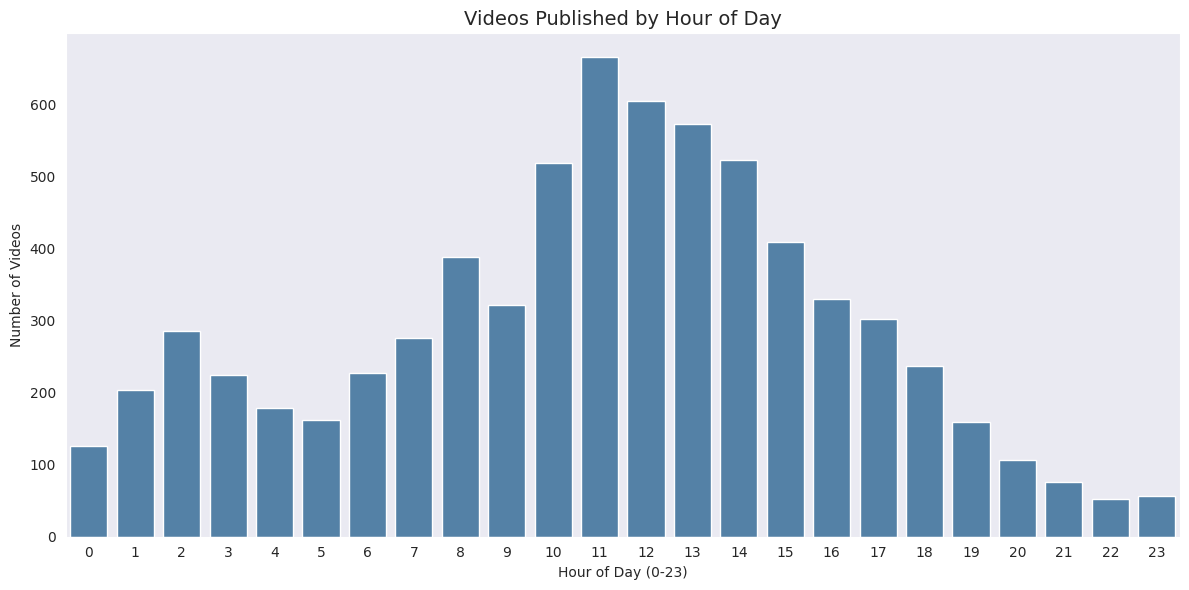

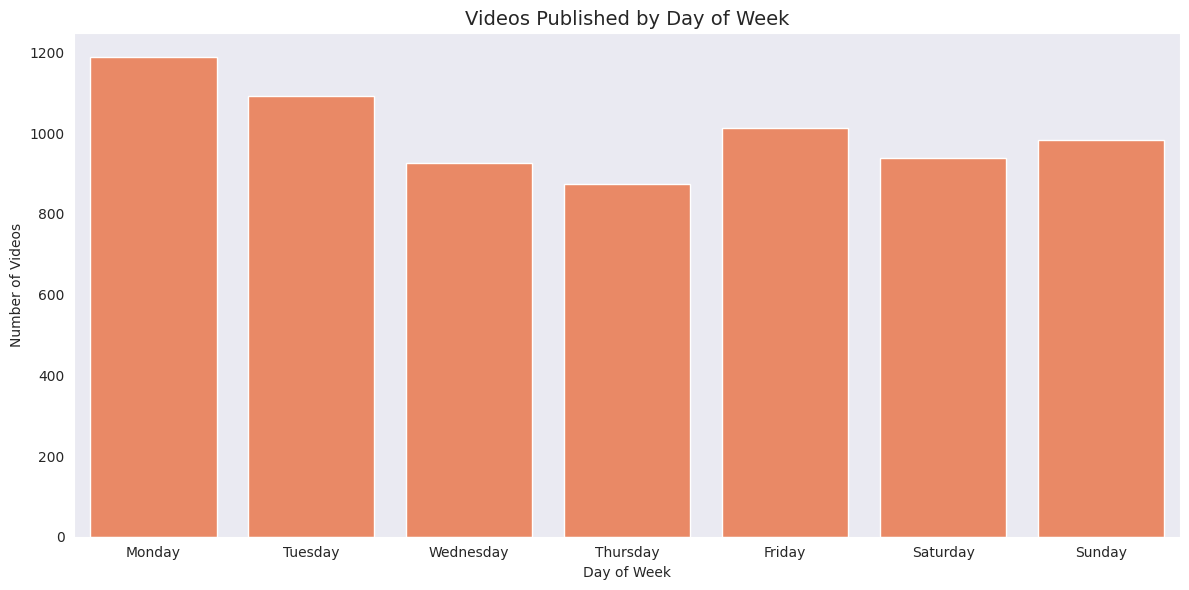

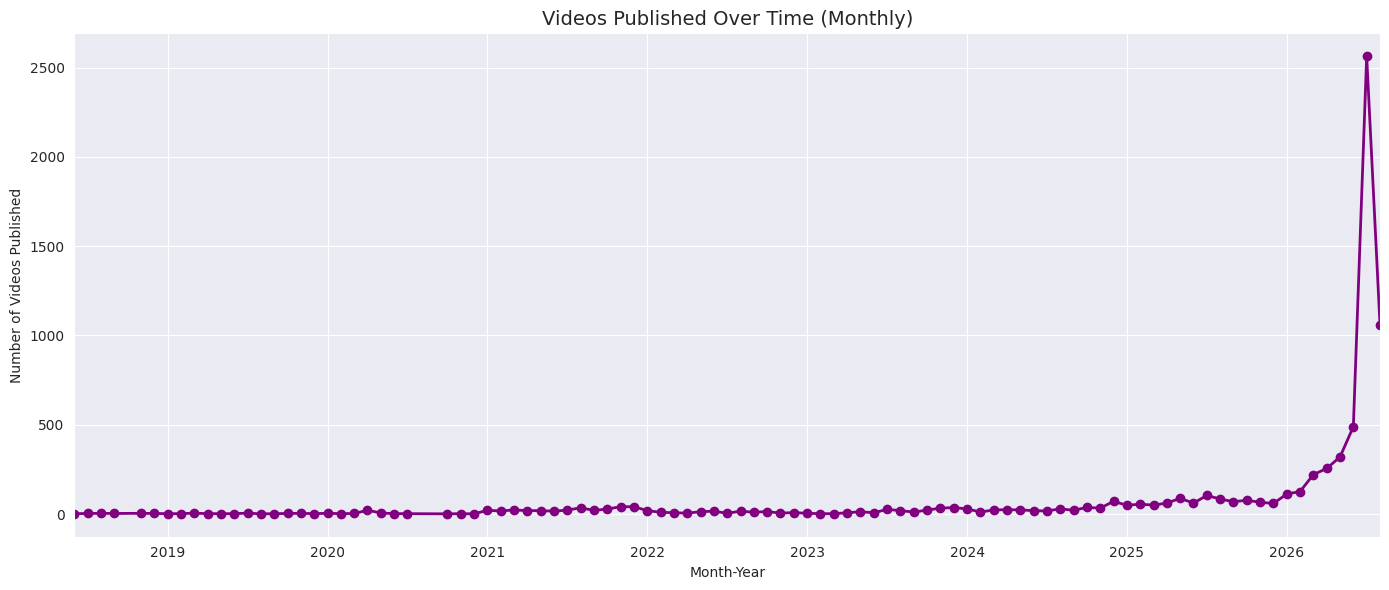

In [8]:
# Extract features from published_at
videos_rows['publish_hour'] = videos_rows['published_at'].dt.hour
videos_rows['publish_day_name'] = videos_rows['published_at'].dt.day_name()
videos_rows['publish_month_year'] = videos_rows['published_at'].dt.to_period('M')

# Videos Published by Hour of Day
plt.figure(figsize=(12, 6))
sns.countplot(x='publish_hour', data=videos_rows, color='steelblue')
plt.title('Videos Published by Hour of Day', fontsize=14)
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Number of Videos')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Videos Published by Day of Week
days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
plt.figure(figsize=(12, 6))
sns.countplot(x='publish_day_name', data=videos_rows, order=days_order, color='coral')
plt.title('Videos Published by Day of Week', fontsize=14)
plt.xlabel('Day of Week')
plt.ylabel('Number of Videos')
plt.grid(axis='y')
plt.tight_layout()
plt.show()

# Videos Published Over Time (Monthly)
monthly_counts = videos_rows['publish_month_year'].value_counts().sort_index()

plt.figure(figsize=(14, 6))
monthly_counts.plot(kind='line', marker='o', color='purple', linewidth=2)
plt.title('Videos Published Over Time (Monthly)', fontsize=14)
plt.xlabel('Month-Year')
plt.ylabel('Number of Videos Published')
plt.grid(True)
plt.tight_layout()
plt.show()


## 5. Early Signal Analysis
This section analyzes early performance metrics and their predictive power for final viewership.
- It compares the view count at the very first scrape (early views) with the latest view count.
- It looks at the timing of the first scrape to understand data collection latency.
- It bins videos by the time of their first scrape and evaluates average final performance.


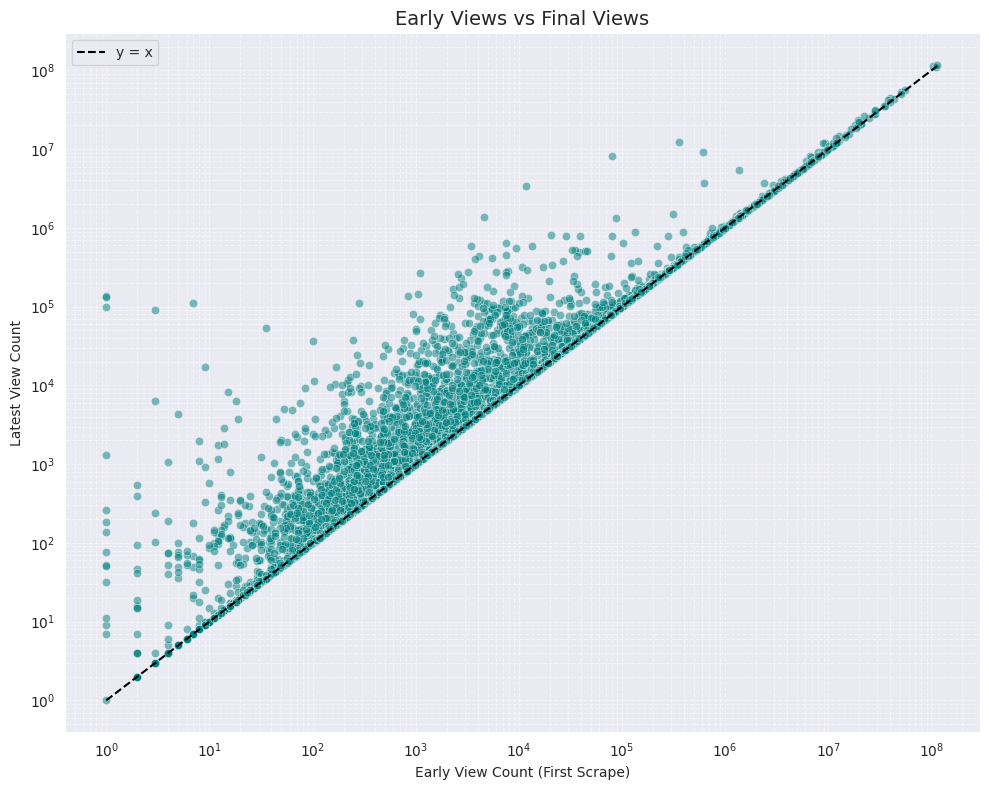

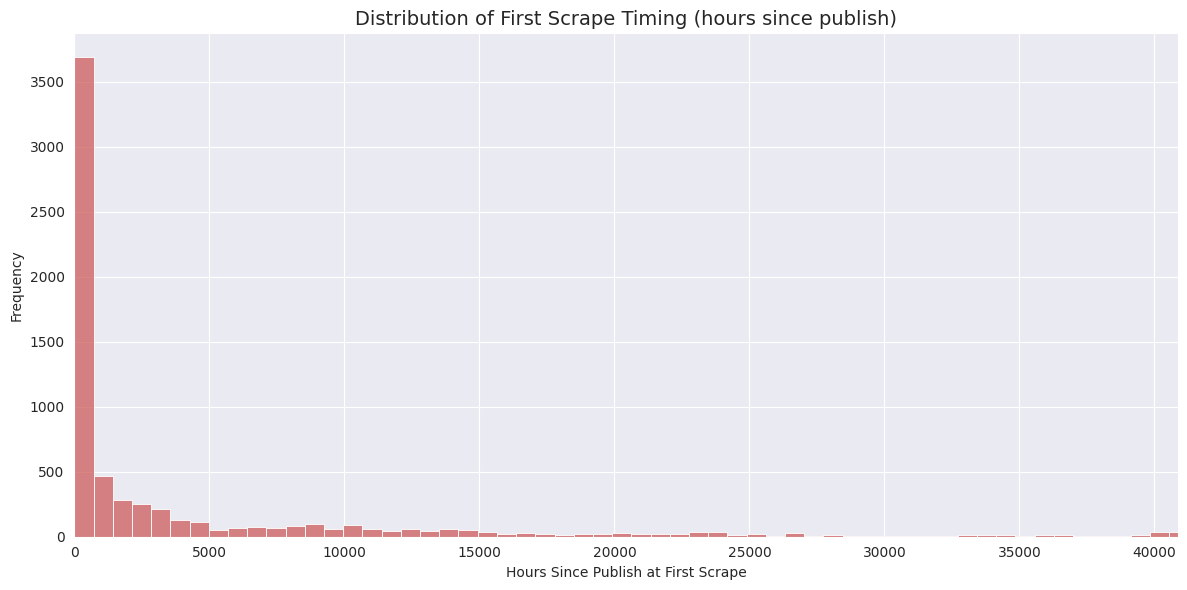

/tmp/ipykernel_2263/373517119.py:57: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=avg_views_by_window.index, y=avg_views_by_window.values, palette='magma')


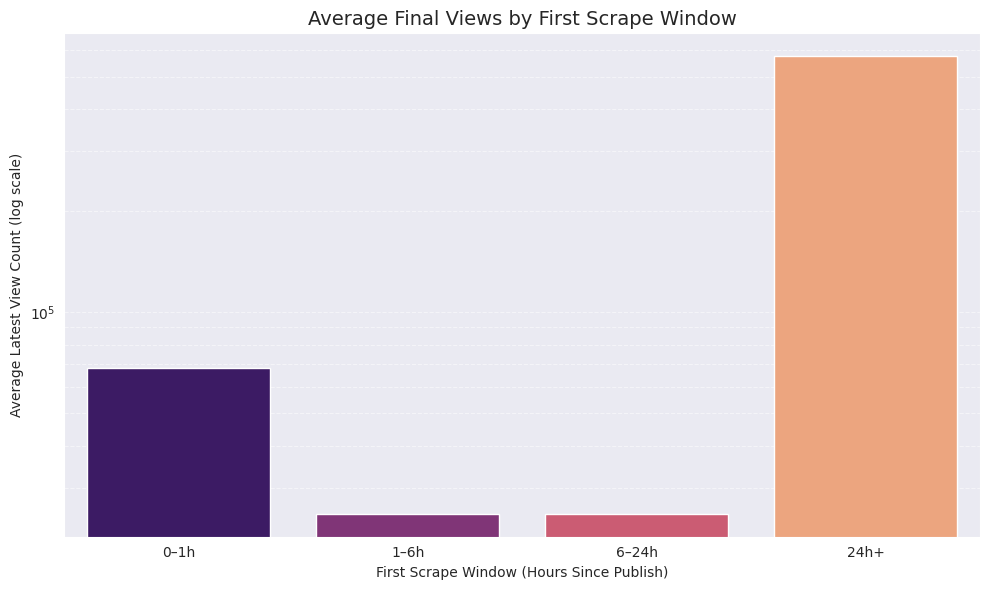

In [9]:
# Rename early snapshot columns for clarity
early_snapshot = early_snapshot.rename(columns={
    'view_count': 'early_view_count',
    'hours_since_publish': 'early_hours_since_publish'
})

# Merge early and latest snapshots
early_latest_merged = pd.merge(
    early_snapshot[['video_id', 'early_view_count', 'early_hours_since_publish']],
    latest_snapshot[['video_id', 'view_count']],
    on='video_id',
    how='inner'
).rename(columns={'view_count': 'latest_view_count'})

# Filter valid non-zero rows for log-log plot
valid_early = early_latest_merged[(early_latest_merged['early_view_count'] > 0) & (early_latest_merged['latest_view_count'] > 0)]

# Early Views vs Final Views
plt.figure(figsize=(10, 8))
sns.scatterplot(x='early_view_count', y='latest_view_count', data=valid_early, alpha=0.5, color='teal')

# Add y=x reference line
min_val = min(valid_early['early_view_count'].min(), valid_early['latest_view_count'].min())
max_val = max(valid_early['early_view_count'].max(), valid_early['latest_view_count'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='y = x')

plt.xscale('log')
plt.yscale('log')
plt.title('Early Views vs Final Views', fontsize=14)
plt.xlabel('Early View Count (First Scrape)')
plt.ylabel('Latest View Count')
plt.legend()
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Distribution of First Scrape Timing
plt.figure(figsize=(12, 6))
sns.histplot(early_latest_merged['early_hours_since_publish'], bins=100, color='indianred')
plt.title('Distribution of First Scrape Timing (hours since publish)', fontsize=14)
plt.xlabel('Hours Since Publish at First Scrape')
plt.ylabel('Frequency')
# Limit x-axis to zoom in on the bulk of the data, as outliers can stretch it
plt.xlim(0, early_latest_merged['early_hours_since_publish'].quantile(0.95))
plt.grid(True)
plt.tight_layout()
plt.show()

# Bin videos into early_hours buckets
bins = [-np.inf, 1, 6, 24, np.inf]
labels = ['0–1h', '1–6h', '6–24h', '24h+']
early_latest_merged['scrape_window'] = pd.cut(early_latest_merged['early_hours_since_publish'], bins=bins, labels=labels)

avg_views_by_window = early_latest_merged.groupby('scrape_window', observed=True)['latest_view_count'].mean()

plt.figure(figsize=(10, 6))
sns.barplot(x=avg_views_by_window.index, y=avg_views_by_window.values, palette='magma')
plt.yscale('log')
plt.title('Average Final Views by First Scrape Window', fontsize=14)
plt.xlabel('First Scrape Window (Hours Since Publish)')
plt.ylabel('Average Latest View Count (log scale)')
plt.grid(axis='y', which='both', ls='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 6. Channel-Level Overview
This section provides an aggregated view of channel performance and tracking metrics.
- The top 15 channels by subscriber count are presented.
- A scatter plot compares channel subscribers with average views per video to see if subscriber base guarantees high views.
- The tracking volume per channel is shown to understand data distribution.


/tmp/ipykernel_2263/1482200806.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='subscriber_count', y='channel_title', data=top_subs, palette='crest')
/tmp/ipykernel_2263/1482200806.py:13: UserWarning: Glyph 3520 (\N{SINHALA LETTER VAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:13: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:13: UserWarning: Glyph 3538 (\N{SINHALA VOWEL SIGN KETTI IS-PILLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:13: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:13: UserWarning: Glyph 3539 (\N{SINHALA VOWEL SIGN DIGA IS-PILLA}) missing

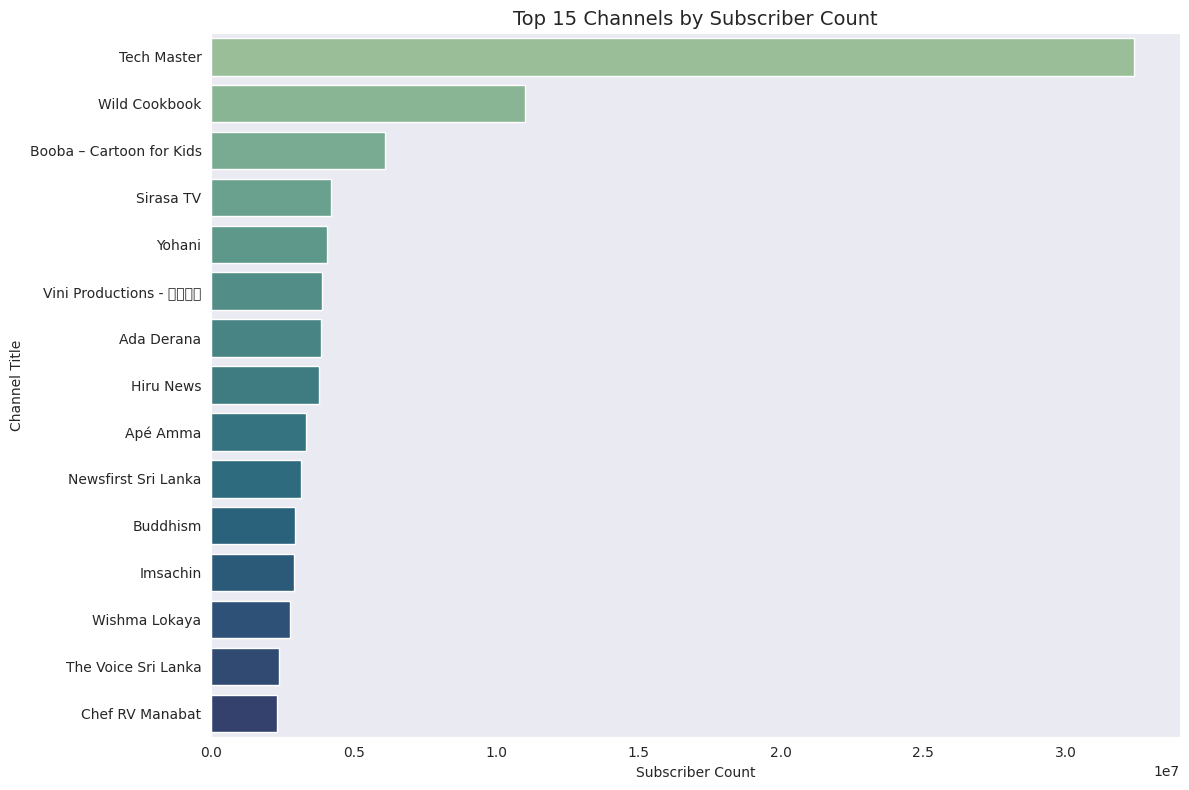

/tmp/ipykernel_2263/1482200806.py:39: UserWarning: Glyph 3461 (\N{SINHALA LETTER AYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:39: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:39: UserWarning: Glyph 3505 (\N{SINHALA LETTER DANTAJA NAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:39: UserWarning: Glyph 3458 (\N{SINHALA SIGN ANUSVARAYA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:39: UserWarning: Glyph 3512 (\N{SINHALA LETTER MAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:39: UserWarning: Glyph 3490 (\N{SINHALA LETTER ALPAPRAANA JAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:39: UserWarning: Glyph 3508 (\N{SINHALA LETTER ALPAPRAANA PAYANNA}) missing from font(s) 

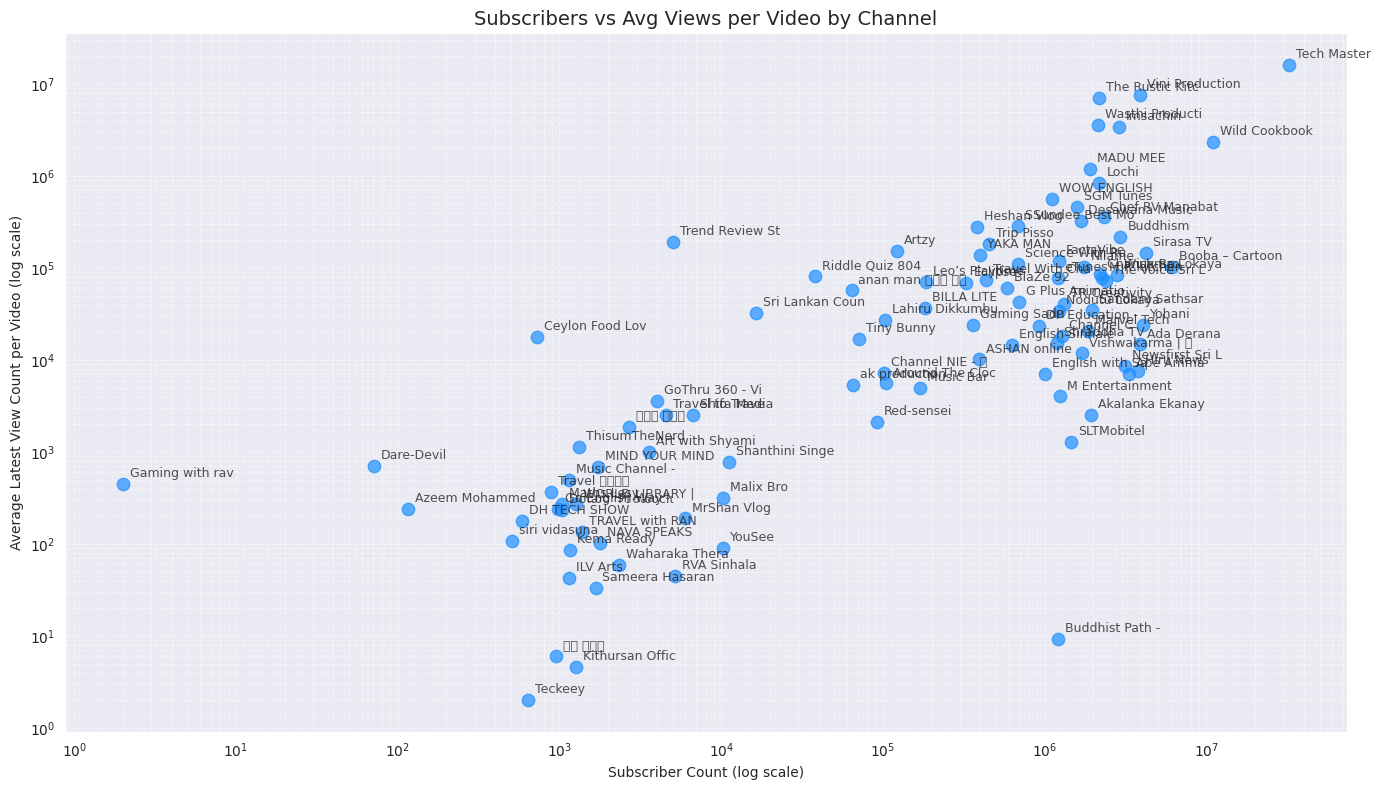

/tmp/ipykernel_2263/1482200806.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_tracked.values, y=top_tracked.index, palette='rocket')
/tmp/ipykernel_2263/1482200806.py:51: UserWarning: Glyph 3520 (\N{SINHALA LETTER VAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:51: UserWarning: Matplotlib currently does not support Sinhala natively.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:51: UserWarning: Glyph 3538 (\N{SINHALA VOWEL SIGN KETTI IS-PILLA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:51: UserWarning: Glyph 3521 (\N{SINHALA LETTER TAALUJA SAYANNA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2263/1482200806.py:51: UserWarning: Glyph 3530 (\N{SINHALA SIGN AL-LAKUNA}) missing from font(s) DejaVu 

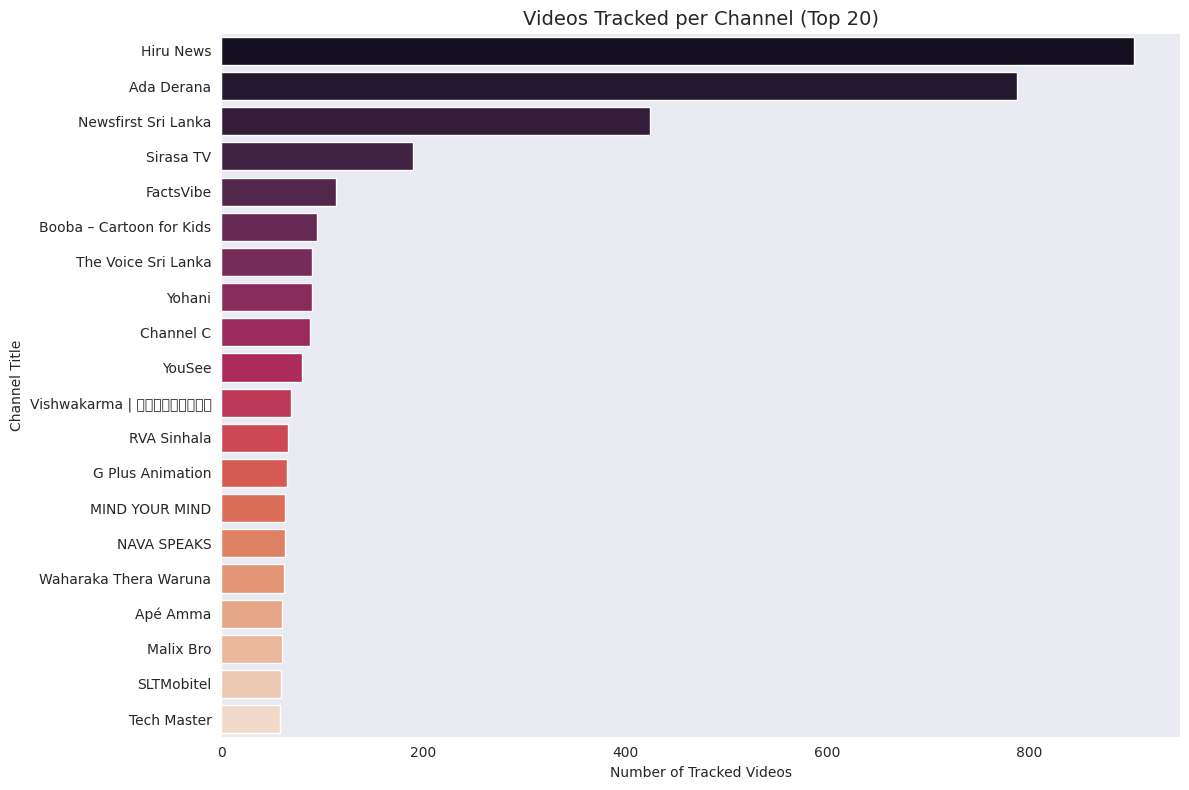

In [10]:
# Ensure subscriber_count is numeric
channel_stats['subscriber_count'] = pd.to_numeric(channel_stats['subscriber_count'], errors='coerce').fillna(0)

# Top 15 Channels by Subscriber Count
top_subs = channel_stats.sort_values('subscriber_count', ascending=False).head(15)

plt.figure(figsize=(12, 8))
sns.barplot(x='subscriber_count', y='channel_title', data=top_subs, palette='crest')
plt.title('Top 15 Channels by Subscriber Count', fontsize=14)
plt.xlabel('Subscriber Count')
plt.ylabel('Channel Title')
plt.grid(axis='x')
plt.tight_layout()
plt.show()

# Subscribers vs Avg Views per Video by Channel
# Aggregate average latest views per channel
avg_views_per_channel = latest_snapshot.groupby('channel_id')['view_count'].mean().reset_index(name='avg_latest_views')
channel_agg = pd.merge(channel_stats, avg_views_per_channel, on='channel_id', how='inner')

# Filter for log scale
valid_agg = channel_agg[(channel_agg['subscriber_count'] > 0) & (channel_agg['avg_latest_views'] > 0)]

plt.figure(figsize=(14, 8))
plt.scatter(valid_agg['subscriber_count'], valid_agg['avg_latest_views'], alpha=0.7, color='dodgerblue', s=80)

# Label each point with short channel_title
for i, row in valid_agg.iterrows():
    plt.annotate(str(row['channel_title'])[:15],
                 (row['subscriber_count'], row['avg_latest_views']),
                 fontsize=9, alpha=0.8, xytext=(5, 5), textcoords='offset points')

plt.xscale('log')
plt.yscale('log')
plt.title('Subscribers vs Avg Views per Video by Channel', fontsize=14)
plt.xlabel('Subscriber Count (log scale)')
plt.ylabel('Average Latest View Count per Video (log scale)')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()

# Videos Tracked per Channel (Top 20)
top_tracked = latest_snapshot['channel_title'].value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_tracked.values, y=top_tracked.index, palette='rocket')
plt.title('Videos Tracked per Channel (Top 20)', fontsize=14)
plt.xlabel('Number of Tracked Videos')
plt.ylabel('Channel Title')
plt.grid(axis='x')
plt.tight_layout()
plt.show()
